Importing Libraries

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.metrics import mean_squared_error

Generate Synthetic Data

In [5]:
X, y = make_blobs(n_samples=300, centers=4, random_state=42, cluster_std=2.0)


K-Means with Centroid = Mean

In [6]:
max_iters = 100
k = 4

centroids_mean = X[np.random.choice(len(X), k, replace=False)]
clusters_mean = []
it_mean = 0


 
for i in range(max_iters):
    it_mean += 1
    current_clusters = [[] for _ in range(k)]
    
    for point in X:
        distances = [np.linalg.norm(point - c) for c in centroids_mean]
        cluster_idx = np.argmin(distances)
        current_clusters[cluster_idx].append(point)
    
    new_centroids = []
    for idx, cluster in enumerate(current_clusters):
        if len(cluster) > 0:
            new_centroids.append(np.mean(cluster, axis=0))
        else:
            new_centroids.append(centroids_mean[idx])
            
    new_centroids = np.array(new_centroids)
    
    if np.allclose(centroids_mean, new_centroids):
        clusters_mean = current_clusters
        break
        
    centroids_mean = new_centroids
    clusters_mean = current_clusters


K-Means with Centroid = Input Points

In [7]:
centroids_rest = X[np.random.choice(len(X), k, replace=False)]
clusters_rest = []
it_rest = 0

for i in range(max_iters):
    it_rest += 1
    current_clusters = [[] for _ in range(k)]
    
    for point in X:
        distances = [np.linalg.norm(point - c) for c in centroids_rest]
        cluster_idx = np.argmin(distances)
        current_clusters[cluster_idx].append(point)
        
    new_centroids = []
    for idx, cluster in enumerate(current_clusters):
        if len(cluster) > 0:
            cluster_arr = np.array(cluster)
            sum_distances = []
            for candidate in cluster_arr:
                d_sum = np.sum([np.linalg.norm(candidate - other) for other in cluster_arr])
                sum_distances.append(d_sum)
            
            best_idx = np.argmin(sum_distances)
            new_centroids.append(cluster_arr[best_idx])
        else:
            new_centroids.append(centroids_rest[idx])
            
    new_centroids = np.array(new_centroids)
    
    if np.allclose(centroids_rest, new_centroids):
        clusters_rest = current_clusters
        break
        
    centroids_rest = new_centroids
    clusters_rest = current_clusters



Calculate Errors for K-Means with centroid = Mean

In [8]:
abs_error_mean = 0
mse_error_mean = 0
for idx, cluster in enumerate(clusters_mean):
    for point in cluster:
        d = np.linalg.norm(point - centroids_mean[idx])
        abs_error_mean += d
        mse_error_mean += d**2


Calculate Errors for K-Means with centroid = Input Points

In [9]:
abs_error_rest = 0
mse_error_rest = 0
for idx, cluster in enumerate(clusters_rest):
    for point in cluster:
        d = np.linalg.norm(point - centroids_rest[idx])
        abs_error_rest += d
        mse_error_rest += d**2



Printing Results

In [10]:
print(f"{'Metric':<25} | {'Standard (Mean)':<15} | {'Restricted (Medoid)':<15}")
print("-" * 65)
print(f"{'Iterations':<25} | {it_mean:<15} | {it_rest:<15}")
print(f"{'Total Absolute Error':<25} | {abs_error_mean:<15.2f} | {abs_error_rest:<15.2f}")
print(f"{'Total MSE':<25} | {mse_error_mean:<15.2f} | {mse_error_rest:<15.2f}")
print("-" * 65)
print(f"Diff in MSE (Restricted - Mean): {mse_error_rest - mse_error_mean:.2f}")
print(f"Diff in Abs (Restricted - Mean): {abs_error_rest - abs_error_mean:.2f}")


Metric                    | Standard (Mean) | Restricted (Medoid)
-----------------------------------------------------------------
Iterations                | 6               | 3              
Total Absolute Error      | 720.20          | 720.89         
Total MSE                 | 2183.45         | 2226.33        
-----------------------------------------------------------------
Diff in MSE (Restricted - Mean): 42.88
Diff in Abs (Restricted - Mean): 0.68


Visualizing

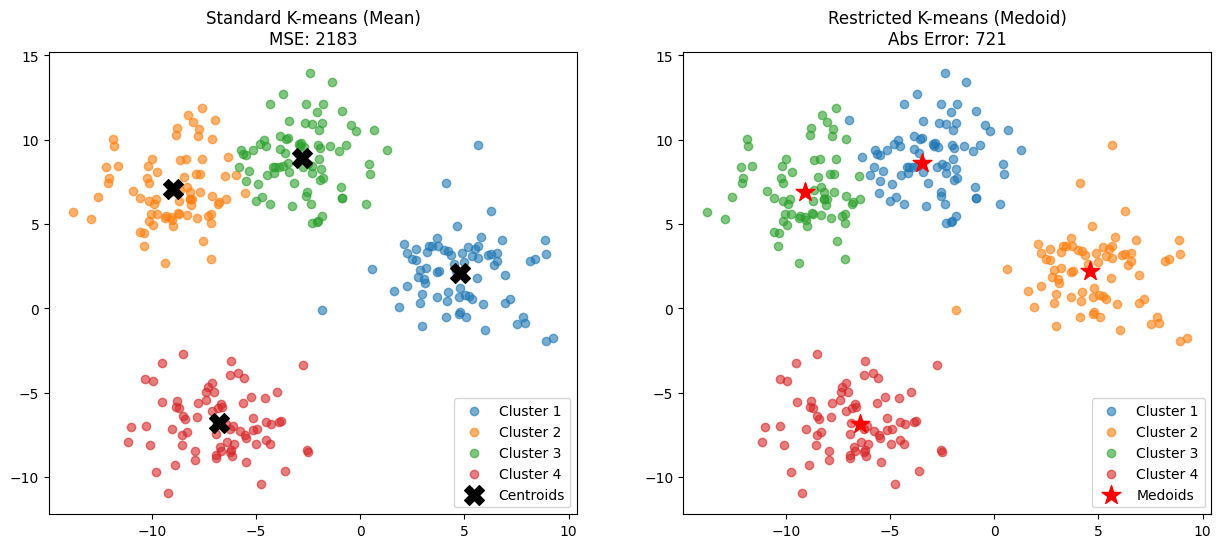

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
for idx, cluster in enumerate(clusters_mean):
    cluster = np.array(cluster)
    if len(cluster) > 0:
        ax[0].scatter(cluster[:, 0], cluster[:, 1], alpha=0.6, label=f'Cluster {idx+1}')
ax[0].scatter(centroids_mean[:, 0], centroids_mean[:, 1], s=200, c='black', marker='X', label='Centroids')
ax[0].set_title(f'Standard K-means (Mean)\nMSE: {mse_error_mean:.0f}')
ax[0].legend()

for idx, cluster in enumerate(clusters_rest):
    cluster = np.array(cluster)
    if len(cluster) > 0:
        ax[1].scatter(cluster[:, 0], cluster[:, 1], alpha=0.6, label=f'Cluster {idx+1}')
ax[1].scatter(centroids_rest[:, 0], centroids_rest[:, 1], s=200, c='red', marker='*', label='Medoids')
ax[1].set_title(f'Restricted K-means (Medoid)\nAbs Error: {abs_error_rest:.0f}')
ax[1].legend()

plt.show()

Standard K-means is significantly faster

Standard K-means produces lower error on both metrics for this dataset.An MSE that is 20% to 25% lower than Restricted K-means.